# 18. Entrenamiento del refiner de profundidad

Este notebook documenta el entrenamiento de una red encoder-decoder pequena para refinar la salida de Depth Pro. El objetivo no es estimar profundidad desde cero, sino aprender una correccion supervisada usando el LiDAR proyectado como referencia sparse.

La perdida se calcula solo en pixeles donde existe GT LiDAR valido.

In [ ]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

FIRST30_DATASET_DIR = ROOT / 'outputs' / 'scene-0061' / 'depth_refinement_dataset_first30'
FULL_DATASET_DIR = ROOT / 'outputs' / 'scene-0061' / 'depth_refinement_dataset'
SMOKE_DATASET_DIR = ROOT / 'outputs' / 'scene-0061' / 'depth_refinement_dataset_front_smoke'

RUN_TRAINING = False
RUN_TRAINING_RGB = False
SPLIT_BY_SAMPLE = True

DATASET_DIR = FIRST30_DATASET_DIR if (FIRST30_DATASET_DIR / 'dataset_index.json').exists() else (FULL_DATASET_DIR if (FULL_DATASET_DIR / 'dataset_index.json').exists() else SMOKE_DATASET_DIR)
TRAINING_DIR = DATASET_DIR / 'refiner_training'
RGB_TRAINING_DIR = DATASET_DIR / 'refiner_training_rgb'

print('Python kernel:', sys.executable)
print('Dataset seleccionado:', DATASET_DIR)
print('Dataset first30:', FIRST30_DATASET_DIR)
print('Dataset first5:', FULL_DATASET_DIR)
print('Dataset smoke:', SMOKE_DATASET_DIR)
print('Training outputs:', TRAINING_DIR)
print('Training RGB outputs:', RGB_TRAINING_DIR)
print('RUN_TRAINING:', RUN_TRAINING)
print('RUN_TRAINING_RGB:', RUN_TRAINING_RGB)
print('SPLIT_BY_SAMPLE:', SPLIT_BY_SAMPLE)

Python kernel: /home/clara/ml-depth-pro/depthpro_env/bin/python
Dataset seleccionado: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30
Dataset first30: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30
Dataset first5: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset
Dataset smoke: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_front_smoke
Training outputs: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training
Training RGB outputs: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb
RUN_TRAINING: False
RUN_TRAINING_RGB: False
SPLIT_BY_SAMPLE: True


## 1. Modelo y objetivo

El script entrena una U-Net residual pequena:

`Depth Pro -> U-Net -> profundidad refinada`

La red predice una correccion limitada sobre Depth Pro. Esto evita que el modelo tenga que aprender toda la profundidad desde cero y mantiene el experimento centrado en refinamiento.

## 2. Entrenamiento desde el notebook

La siguiente celda permite lanzar el entrenamiento directamente desde el notebook. La variante `solo-depth` se mantiene como baseline opcional, mientras que la configuración recomendada para los resultados presentables es `Depth Pro + RGB`.

Por defecto, el notebook no vuelve a entrenar el modelo, sino que carga los resultados ya generados mediante comandos. Para regenerarlos desde aquí, sirve con activar `RUN_TRAINING_RGB = True`.

La partición por sample está activada mediante `SPLIT_BY_SAMPLE = True`, de forma que las muestras de entrenamiento y validación quedan separadas a nivel de sample. Si se quiere reproducir el comportamiento anterior, puede cambiarse a `False`, lo que es similar a ejecutar el entrenamiento con `--no-split-by-sample`.

Es importante tener en cuenta que un único ejemplo en modo smoke no permite entrenar un modelo útil. Esta opción sirve únicamente para comprobar que el código se ejecuta correctamente. Para un entrenamiento real, primero debe generarse el dataset completo.

In [2]:
split_flag = '--split-by-sample' if SPLIT_BY_SAMPLE else '--no-split-by-sample'

index_path = DATASET_DIR / 'dataset_index.json'
if not index_path.exists():
    print('No existe dataset_index:', index_path)
    print('Ejecuta primero el notebook 17 para generar el dataset.')
else:
    index = json.loads(index_path.read_text(encoding='utf-8-sig'))
    print('Entradas disponibles:', index['num_entries'])

    if index['num_entries'] < 4:
        epochs = '1'
        batch_size = '1'
        extra_args = ['--val-ratio', '0.5', '--base-channels', '8']
        print('Aviso: dataset muy pequeno. Se configura como smoke test, no como entrenamiento real.')
    else:
        epochs = '20'
        batch_size = '2'
        extra_args = []

    train_cmd = [
        sys.executable,
        str(ROOT / 'scripts' / 'train_depth_refiner.py'),
        '--dataset-dir', str(DATASET_DIR),
        '--output-dir', str(TRAINING_DIR),
        '--epochs', epochs,
        '--batch-size', batch_size,
        split_flag,
        *extra_args,
    ]

    print(' '.join(train_cmd))

    if RUN_TRAINING:
        subprocess.run(train_cmd, cwd=str(ROOT), check=True)
    else:
        print('No se ha ejecutado. Cambia RUN_TRAINING a True para entrenar.')

Entradas disponibles: 180
/home/clara/ml-depth-pro/depthpro_env/bin/python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/train_depth_refiner.py --dataset-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30 --output-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training --epochs 20 --batch-size 2 --split-by-sample
No se ha ejecutado. Cambia RUN_TRAINING a True para entrenar.


## 3. Baseline de Depth Pro sin refinar

Antes de interpretar el entrenamiento, hay que comparar contra la profundidad original de Depth Pro en los mismos pixeles LiDAR validos. Si el refiner no mejora este baseline, no se deberia usar para generar pseudo-LiDAR.

In [3]:
baseline_path = TRAINING_DIR / 'baseline_depth_pro_metrics.json'

if not baseline_path.exists():
    print('Todavia no existe:', baseline_path)
    print('Ejecuta primero el entrenamiento para generar el baseline.')
else:
    baseline = json.loads(baseline_path.read_text(encoding='utf-8-sig'))
    display(pd.DataFrame(baseline).T)

Todavia no existe: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training/baseline_depth_pro_metrics.json
Ejecuta primero el entrenamiento para generar el baseline.


## 4. Curvas de entrenamiento

Esta seccion carga `training_history.json` y `training_curves.png` si ya existen. Las metricas principales son MAE y RMSE en metros, calculadas solo sobre los pixeles con GT LiDAR valido.

In [4]:
history_path = TRAINING_DIR / 'training_history.json'
curves_path = TRAINING_DIR / 'training_curves.png'

if not history_path.exists():
    print('Todavia no existe:', history_path)
else:
    history = pd.DataFrame(json.loads(history_path.read_text(encoding='utf-8-sig')))
    display(history)
    if curves_path.exists():
        display(Image(filename=str(curves_path)))

Todavia no existe: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training/training_history.json


## 5. Checkpoint generado

El mejor modelo se guarda como `best_depth_refiner.pt`. Ese checkpoint se usara para comparar Depth Pro original frente a profundidad refinada.

In [5]:
checkpoint_path = TRAINING_DIR / 'best_depth_refiner.pt'
if checkpoint_path.exists():
    print('Checkpoint:', checkpoint_path)
else:
    print('No existe checkpoint todavia:', checkpoint_path)

No existe checkpoint todavia: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training/best_depth_refiner.pt


## 6. Interpretación esperada

El refinamiento solo puede considerarse útil si reduce el error respecto al baseline de Depth Pro en el conjunto de validación. Si el error disminuye en entrenamiento pero no en validación, lo más probable es que el modelo esté sobreajustando, especialmente si el número de samples disponibles es reducido.

En caso de observar una mejora consistente, el siguiente paso consiste en aplicar el checkpoint entrenado a las profundidades de la escena, regenerar el pseudo-LiDAR y repetir las métricas 3D y de registro temporal.

## 7. Variante principal: RGB + Depth Pro

La variante recomendada recibe el mapa de profundidad de Depth Pro y la imagen RGB: la entrada pasa a ser `[Depth Pro, R, G, B]`.

La idea es que la red pueda usar bordes y apariencia de la imagen para corregir mejor zonas como vehiculos, fachadas, vegetacion o limites de carretera. El checkpoint se guarda en otra carpeta para no sobrescribir el modelo anterior.

In [6]:
split_flag = '--split-by-sample' if SPLIT_BY_SAMPLE else '--no-split-by-sample'

index_path = DATASET_DIR / 'dataset_index.json'
if not index_path.exists():
    print('No existe dataset_index:', index_path)
    print('Ejecuta primero el notebook 17 para generar el dataset.')
else:
    index = json.loads(index_path.read_text(encoding='utf-8-sig'))
    print('Entradas disponibles:', index['num_entries'])
    if index['num_entries'] < 4:
        epochs = '1'
        batch_size = '1'
        extra_args = ['--val-ratio', '0.5', '--base-channels', '8']
        print('Aviso: dataset muy pequeno. Variante RGB solo como smoke test.')
    else:
        epochs = '30'
        batch_size = '2'
        extra_args = []

    train_rgb_cmd = [
        sys.executable,
        str(ROOT / 'scripts' / 'train_depth_refiner.py'),
        '--dataset-dir', str(DATASET_DIR),
        '--output-dir', str(RGB_TRAINING_DIR),
        '--epochs', epochs,
        '--batch-size', batch_size,
        split_flag,
        '--use-rgb',
        *extra_args,
    ]

    print(' '.join(train_rgb_cmd))
    if RUN_TRAINING_RGB:
        subprocess.run(train_rgb_cmd, cwd=str(ROOT), check=True)
    else:
        print('No se ha ejecutado. Cambia RUN_TRAINING_RGB a True para entrenar la variante RGB + Depth Pro.')

Entradas disponibles: 180
/home/clara/ml-depth-pro/depthpro_env/bin/python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/train_depth_refiner.py --dataset-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30 --output-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb --epochs 30 --batch-size 2 --split-by-sample --use-rgb
No se ha ejecutado. Cambia RUN_TRAINING_RGB a True para entrenar la variante RGB + Depth Pro.


## 8. Comparacion entre la red solo-depth y la red RGB + Depth Pro

Esta tabla deja la red solo-depth como ablation y usa la variante RGB como candidata principal. La comparacion clave sigue siendo contra Depth Pro sin refinar en validacion.

,modelo,metric_source,split_note,split_by_sample,use_rgb,train_entries,val_entries,depth_pro_val_mae_m,best_val_mae_m,best_val_mae_epoch,delta_mae_vs_depth_pro_m,depth_pro_val_rmse_m,best_val_rmse_m,best_val_rmse_epoch,delta_rmse_vs_depth_pro_m,checkpoint
0,Depth Pro + RGB,refined_depth_eval,sample_token_grouped_split,True,True,144,36,4.113208,2.838228,21,-1.27498,29.37844,5.907853,15,-23.470588,/home/clara/ml-depth-pro/slam_readiness_nuscen...


/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/training_curves.png


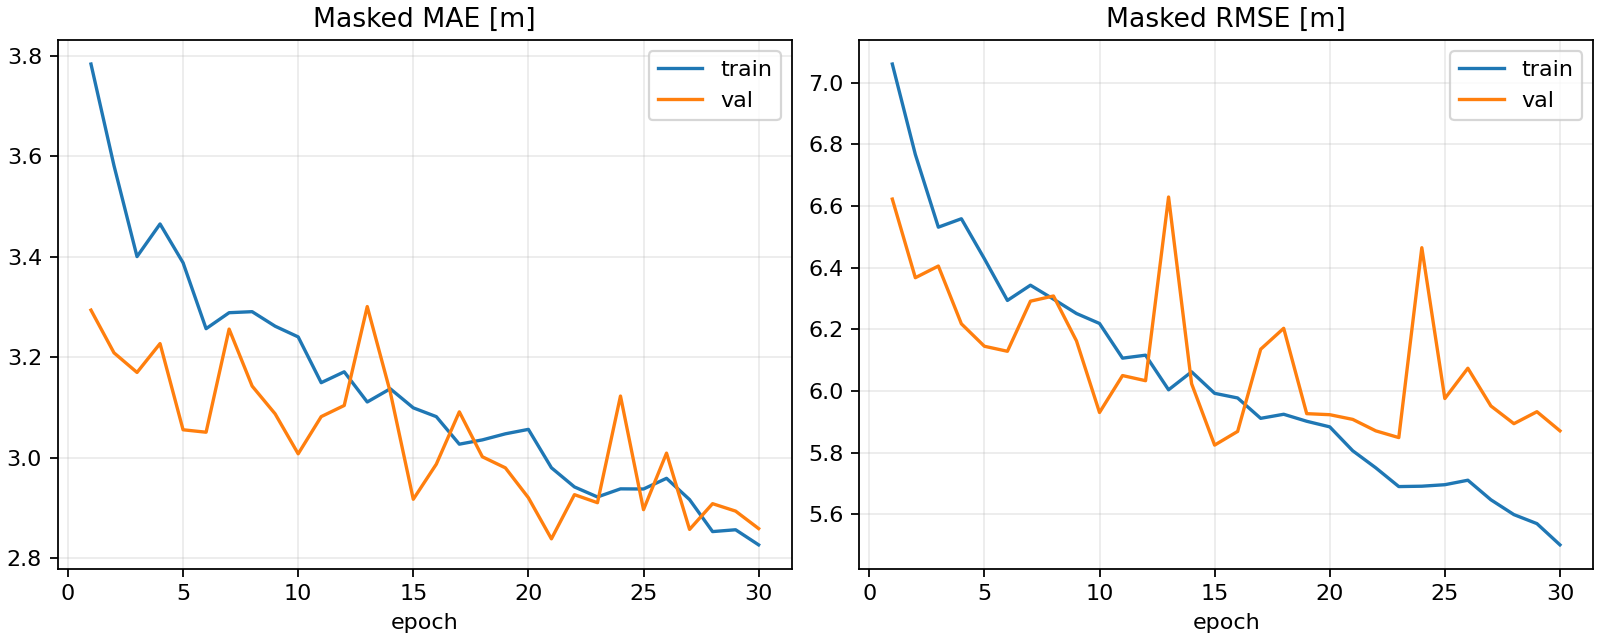

In [7]:
def summarize_training(name, training_dir):
    baseline_path = training_dir / 'baseline_depth_pro_metrics.json'
    history_path = training_dir / 'training_history.json'
    eval_path = training_dir / 'refined_depth_eval.json'
    if not baseline_path.exists() or not history_path.exists():
        return None
    baseline = json.loads(baseline_path.read_text(encoding='utf-8-sig'))
    history = pd.DataFrame(json.loads(history_path.read_text(encoding='utf-8-sig')))
    best = history.loc[history['val_mae_m'].idxmin()]
    best_rmse = history.loc[history['val_rmse_m'].idxmin()]

    metric_source = 'training_history'
    depth_pro_mae = baseline['val_depth_pro']['mae_m']
    depth_pro_rmse = baseline['val_depth_pro']['rmse_m']
    refined_mae = float(best['val_mae_m'])
    refined_rmse = float(best_rmse['val_rmse_m'])
    if eval_path.exists():
        eval_data = json.loads(eval_path.read_text(encoding='utf-8-sig'))
        eval_metrics = eval_data.get('aggregate', eval_data)
        depth_pro_mae = eval_metrics['depth_pro']['mae_m']
        depth_pro_rmse = eval_metrics['depth_pro']['rmse_m']
        refined_mae = eval_metrics['refined']['mae_m']
        refined_rmse = eval_metrics['refined']['rmse_m']
        metric_source = 'refined_depth_eval'

    return {
        'modelo': name,
        'metric_source': metric_source,
        'split_note': baseline.get('split_note'),
        'split_by_sample': baseline.get('split_by_sample'),
        'use_rgb': baseline.get('use_rgb'),
        'train_entries': baseline.get('num_train_entries'),
        'val_entries': baseline.get('num_val_entries'),
        'depth_pro_val_mae_m': depth_pro_mae,
        'best_val_mae_m': refined_mae,
        'best_val_mae_epoch': int(best['epoch']),
        'delta_mae_vs_depth_pro_m': float(refined_mae - depth_pro_mae),
        'depth_pro_val_rmse_m': depth_pro_rmse,
        'best_val_rmse_m': refined_rmse,
        'best_val_rmse_epoch': int(best_rmse['epoch']),
        'delta_rmse_vs_depth_pro_m': float(refined_rmse - depth_pro_rmse),
        'checkpoint': str(training_dir / 'best_depth_refiner.pt'),
    }

summaries = [
    summarize_training('Depth Pro solo', TRAINING_DIR),
    summarize_training('Depth Pro + RGB', RGB_TRAINING_DIR),
]
summaries = [item for item in summaries if item is not None]

if not summaries:
    print('Todavia no hay resultados de entrenamiento para comparar.')
else:
    comparison_df = pd.DataFrame(summaries)
    display(comparison_df)
    for training_dir in [TRAINING_DIR, RGB_TRAINING_DIR]:
        curves = training_dir / 'training_curves.png'
        if curves.exists():
            print(curves)
            display(Image(filename=str(curves)))

## 9. Conclusiones del entrenamiento del modelo

El entrenamiento de la U-Net residual con entrada `Depth Pro + RGB` muestra una mejora clara respecto a la profundidad original estimada por Depth Pro en los píxeles supervisados por LiDAR.

Al ampliar el conjunto a 30 samples y mantener una partición por sample, el modelo reduce el MAE de validación de `4.11 m` a `2.84 m`. Además, no se observan indicios claros de sobreajuste fuerte, ya que la mejora no se limita únicamente al conjunto de entrenamiento.

Estos resultados indican que el refinamiento aprende una corrección útil sobre la salida de Depth Pro, antes de regenerar la pseudo-LiDAR 3D y evaluar su impacto en las métricas geométricas y de registro temporal.